# Random Processes

To read more about random processes, view the [textbook chapter](https://inferentialthinking.com/chapters/09/Randomness.html) on randomness.

In [2]:
# Importing packages!
import numpy as np
import matplotlib.pyplot as plt

## Introduction to Probability with Coin Flipping

To understand random processes, it's first important to learn and understand the basics of probability. Let's examine probability in terms of coin flips.

A coin has two sides: heads and tails. If you have an average coin with no defects, then there is equal probability to flip the coin and land on either heads or tails. So, for one coin flip, the probability of landing on heads, $P(H)$, is $0.5$, while the probability of landing on tails, $P(T)$, is $0.5$.


To determine the probability of flipping five consecutive heads, we can multiple the probability of landing on heads five times. Therefore, the probability of five consecutive heads is<br>
$$P(H) \cdot P(H) \cdot P(H) \cdot P(H) \cdot P(H) = \frac{1}{32}$$

This is same as probability of zero heads in five flips<br>
$$P(T) \cdot P(T) \cdot P(T) \cdot P(T) \cdot P(T) = \frac{1}{32}$$

In [31]:
# The probability of only heads in five flips
(1/2)*(1/2)*(1/2)*(1/2)*(1/2)

0.03125

What is the probability of having one head in five flips?

If we flip a coin five times, then that single head flip could be the first, second, etc. flip out of the five. So, when calculating the probability, we sum the probabilities of those five scenarios.

Therefore, the probability of exactly one head in five flips is<br>
$$P(H) \cdot P(T) \cdot P(T) \cdot P(T) \cdot P(T)\ +$$
$$P(T) \cdot P(H) \cdot P(T) \cdot P(T) \cdot P(T)\ +$$
$$P(T) \cdot P(T) \cdot P(H) \cdot P(T) \cdot P(T)\ +$$
$$P(T) \cdot P(T) \cdot P(T) \cdot P(H) \cdot P(T)\ +$$
$$P(T) \cdot P(T) \cdot P(T) \cdot P(T) \cdot P(H)\ +$$
$$= \frac{5}{32}$$

In [32]:
# The probablity of only one head in five flips
((1/2)*(1/2)*(1/2)*(1/2)*(1/2)) * 5

0.15625

The probability of exactly two or more heads in five flips can be calculated by subtracting the probability of getting zero heads and the probability of getting exactly one head from the value one. Therefore, the probability of two or more heads in five flips is<br>
$$1 - P(zero\ heads) - P(one\ head) = \frac{26}{32}$$

In [33]:
# The probability of two or more heads in five flips
1 - (1/32) - (5/32)

0.8125

## Simulating Coin Flipping

Now that we understand basic probability concepts, especially when it comes to coin flipping, we can simulate the random processes of coin flipping using Python.

Within the `numpy` library, there is the function `choice()`in the `random` module. `np.random.choice()` allows us to simulate a random choice from a list of values. You can make a single random choice, or you can make multiple random choices, which results in a list of random choice values.

In [34]:
# Flips a coin once
one_flip = np.random.choice(['heads','tails'])
# Flips a coin 5 times
five_flips = np.random.choice(['heads','tails'], 5)

# Prints the results
print(f'The result of one coin flip is {one_flip}.')
print(f'The results of five coin flips are {five_flips}.')

The result of one coin flip is heads.
The results of five coin flips are ['heads' 'tails' 'tails' 'heads' 'heads'].


We can simulate coin flips many time. Below, we run 10 simulations of five coins flips.

In [35]:
# Performs 10 simulations
for each_flip in range(10):
    # Flips coins five times
    outcomes = np.random.choice(['heads','tails'], 5)
    # Prints the outcomes
    print(f'Outcomes of simulation {each_flip + 1}: {outcomes}')

Outcomes of simulation 1: ['heads' 'heads' 'heads' 'tails' 'tails']
Outcomes of simulation 2: ['tails' 'heads' 'heads' 'tails' 'tails']
Outcomes of simulation 3: ['heads' 'tails' 'heads' 'heads' 'heads']
Outcomes of simulation 4: ['tails' 'tails' 'heads' 'heads' 'heads']
Outcomes of simulation 5: ['heads' 'tails' 'heads' 'heads' 'tails']
Outcomes of simulation 6: ['heads' 'tails' 'tails' 'tails' 'tails']
Outcomes of simulation 7: ['tails' 'heads' 'heads' 'heads' 'tails']
Outcomes of simulation 8: ['tails' 'heads' 'tails' 'heads' 'heads']
Outcomes of simulation 9: ['tails' 'heads' 'tails' 'heads' 'tails']
Outcomes of simulation 10: ['heads' 'heads' 'tails' 'tails' 'tails']


We can calculate the number of outcomes for a scenario by using `sum()`.

In [37]:
# Calculates the number of outcomes where the coin lands on heads
outcomes = np.random.choice(['heads','tails'], 5)

# Prints the outcomes
print(f'The outcomes of five random flips are {outcomes}.')
print(f'The number of heads is {sum(outcomes == 'heads')}.')

The outcomes of five random flips are ['heads' 'heads' 'tails' 'tails' 'tails'].
The number of heads is 2.


Let's explore a coin flipping scenario. What is the probability that we will land on tails three times when performing ten coin flips? Let's determine this by simulating coin flips many times, then checking if three tails are flipped and calculating the overall probability.

In [38]:
# Creates a counter to keep track of flips with three tails
three_tails_count = 0

# Sets the number of simulations
num_simulations = 7500

# Performs 7500 coin flip simulations
for each_flip in range(num_simulations):

    # Determines the outcome of 10 coin flips
    outcomes = np.random.choice(['heads','tails'], 10)
    # Counts the number of tails using sum()
    num_tails = sum(outcomes == 'tails')

    # Checks if the number of tails is three
    if num_tails == 3:
        # Increments the number of counts of flips with three tails
        three_tails_count += 1

# Calculates the probability of three tails in ten flips
three_tails_probability = three_tails_count/num_simulations
# Prints the outcome
print(f'The probability that the coin lands on tails three times after ten coin flips is {three_tails_probability}.')

The probability that the coin lands on tails three times after ten coin flips is 0.11866666666666667.


Now, we approximately know the probability that the coin lands on tails three times after ten coin flips. However, what is the overall distribution of tails counts when performing a coin flip ten times? Does our answer make sense? Let's code a simulation to answer this.

In [39]:
# Creates a list that keeps track of tail counts
tail_count_list = []

# Sets the number of simulations
num_simulations = 7500

# Performs 7500 coin flip simulations
for each_flip in range(num_simulations):

    # Determines the outcome of 10 coin flips
    outcomes = np.random.choice(['heads','tails'], 10)
    # Counts the number of tails using sum()
    num_tails = sum(outcomes == 'tails')

    # Adds the tail counts to the tail_counts list
    tail_count_list.append(num_tails)

# Uses np.unique with return_counts to return the counts of each tail counts value
(tail_values, tail_counts) = np.unique(np.array(tail_count_list), return_counts = True)
print(f'These are the tails values: {tail_values}')
print(f'These are the corresponding tails counts: {tail_counts}')
print()

# Calculates the proportion for each count of tails per ten flips
for index, tail_num in enumerate(tail_values):
    print(f'The proportion of flips with {tail_num} tail(s) is {tail_counts[index]/num_simulations}.')

These are the tails values: [ 0  1  2  3  4  5  6  7  8  9 10]
These are the corresponding tails counts: [   3   73  345  867 1544 1854 1496  880  343   88    7]

The proportion of flips with 0 tail(s) is 0.0004.
The proportion of flips with 1 tail(s) is 0.009733333333333333.
The proportion of flips with 2 tail(s) is 0.046.
The proportion of flips with 3 tail(s) is 0.1156.
The proportion of flips with 4 tail(s) is 0.20586666666666667.
The proportion of flips with 5 tail(s) is 0.2472.
The proportion of flips with 6 tail(s) is 0.19946666666666665.
The proportion of flips with 7 tail(s) is 0.11733333333333333.
The proportion of flips with 8 tail(s) is 0.045733333333333334.
The proportion of flips with 9 tail(s) is 0.011733333333333333.
The proportion of flips with 10 tail(s) is 0.0009333333333333333.


We can plot these counts to make visualizing the distribution easier.

Text(0.5, 1.0, 'The Distribution of Tails Landings after Ten Coin Flips')

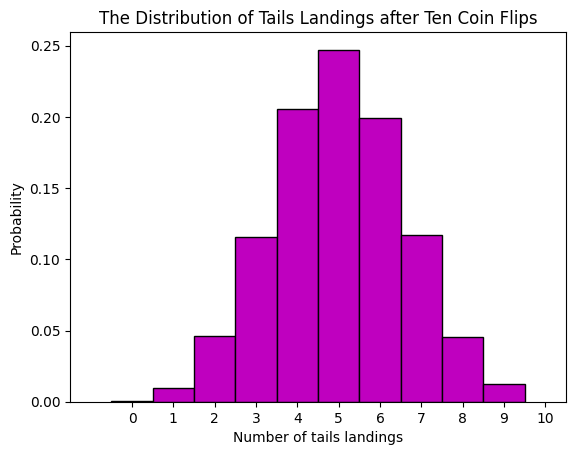

In [40]:
fig, ax1 = plt.subplots()

# Plots histogram of tails probabilities (using density = True for probability)
ax1.hist(tail_count_list, bins = range(11), density = True, color = 'm', ec = 'k', align = 'left')

# Specifies x-axis information
ax1.set_xticks(range(11))
ax1.margins(x = .1)

# Labels plot
ax1.set_xlabel('Number of tails landings')
ax1.set_ylabel('Probability')
ax1.set_title('The Distribution of Tails Landings after Ten Coin Flips')

Our tail flip distributions form a normal distribution, and five tails is seen to be the most frequent number of tail landings in one coin flip simulation. Our probability for three flips in this distributions matches our probability from earlier! 

## Simulations with More than Two Outcomes

Suppose you have a deck of cards, containing an equal number of cards from the hearts, diamonds, clubs, and spades suits. If you randomly draw eight cards, replacing the drawn card each time, what's the probability that you'll draw exactly two hearts and one club?

This scenario is slightly different than coin flipping, because we're examining two different outcomes. The only differences in code are that two types of information are tracked and checked, rather than one!

In [5]:
# Creates a counter for the number of matches
match_count = 0

# Sets the number of simulations
num_simulations = 1000

# Simulates 1000 draws
for each_draw in range(num_simulations):

    # Draws eight times, replacing after each draw
    cards = np.random.choice(['hearts', 'diamonds', 'clubs', 'spades'], 8)

    # Counts number of hearts drawn
    hearts_count = sum(cards == 'hearts')
    # Counts number of clubs drawn
    clubs_count = sum(cards == 'clubs')
    
    # Determines if two hearts and one club have been drawn
    if (hearts_count == 2) & (clubs_count == 1):
        # Adds to match count if condition is met
        match_count += 1

# Calculates probability
prob_estimate = match_count/num_simulations

print(f'The probability that two hearts and one club are drawn is {prob_estimate}.')

The probability that two hearts and one club are drawn is 0.077.


## The Birthday Problem

Assuming that birthdays are evenly distributed across 365 days a year, what is the probability of two members of our class having the same birthday?

Let's define a few functions to help us calculate this probability:
- `get_birthdays()`: Takes an integer input of class size and returns an array of 'birthdays' from 0-364.
- `count_matched_birthdays()`: Takes an array input of birthdays and returns the number of days for which there is a match.
- `calculate_probability()`: Takes an input of class class and the number of simulations and returns the probability of a match for that class size.

Let's first define `get_birthdays()`. We'll use `np.random.choice()` to generate a list of birthdays from each possible day of the year. The number of random draws is equal to the size of the group.

In [8]:
def get_birthdays(group_size):
    # Randomly generates a list of birthdays
    birthdays = np.random.choice(range(365), group_size)
    # Returns the list of birthdays
    return birthdays

In `count_matched_birthdays()`, we'll utilize `np.unique()` with `return_counts = True` to determine the number of matched birthdays.

In [ ]:
def count_matched_birthdays(birthdays):
    # Gets the values and counts for the birthdays in the birthdays array
    birthday_values, birthday_counts = np.unique(birthdays, return_counts = True)
    # Calculates the number of matched birthdays
    matches = sum(birthday_counts > 1)
    # Returns the number of days where there is a match
    return matches

`calculate_probability()` will perform the birthday problem simulation and utilize the `get_birthdays()` and `count_matched_birthdays()` functions for the simulation.

In [10]:
def calculate_probability(num_simulations, groupsize):
    # Creates a counter for keeping track of matching birthdays
    match_count = 0

    # Runs the inputted number of simulations
    for sim in range(num_simulations):
        # Gets the array of birthdays using get_birthdays()
        birthdays = get_birthdays(groupsize)
        # Counts the number of matched birthdays
        matches = count_matched_birthdays(birthdays)

        # Checks if there is at least one match
        if matches > 0:
            # Increments the count of matches by one
            match_count += 1

    # Calculates the probability of birthday matches
    match_prob = match_count/num_simulations
    # Returns the match probability
    return match_prob

Let's try out the simulation!

In [41]:
# Calculates the probabilities with 1000 simulations and 25 people
print(f'The probability of a matching birthday is {calculate_probability(1000, 25)}.')

The probability of a matching birthday is 0.583.


We can calculate the probabilities of matched birthdays for various group sizes to examine how the probability changes as group size increases.

In [42]:
# Sets the number of simulations
num_simulations = 1000
# Sets the various class sizes
class_sizes = [2, 4, 8, 16, 32, 64, 128, 256]
# Creates a probability array for each class
prob_array = np.zeros(len(class_sizes))

# Runs the birthday simulation for each class size
for ind, val in enumerate(class_sizes):
    prob_array[ind] = calculate_probability(num_simulations, val)

print(f'The probabilities for increasing class sizes are {prob_array}.') 

The probabilities for increasing class sizes are [0.    0.019 0.083 0.294 0.771 0.998 1.    1.   ].


Let's visualize this probability array to make the trend in probability more apparent.

Text(0.5, 1.0, 'The Probability of a Matched Birthday for Various Class Sizes')

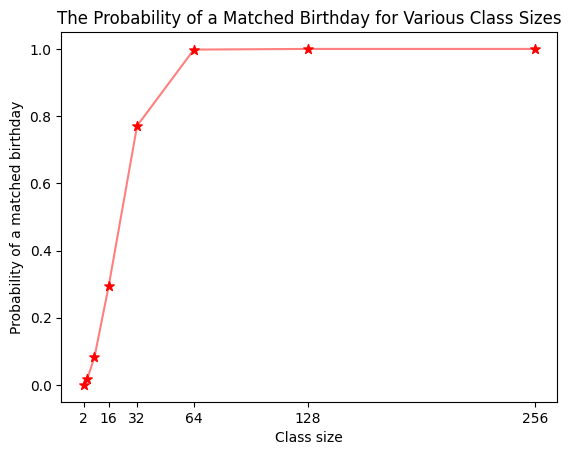

In [43]:
fig,ax2 = plt.subplots()

# Plots the probability data
ax2.plot(class_sizes, prob_array, color = 'r', alpha = 0.5)
ax2.scatter(class_sizes, prob_array, color = 'r', s = 50, marker = '*')

# Sets the axis ticks
ax2.set_xticks([2, 16, 32, 64, 128, 256])

# Labels the plot
ax2.set_xlabel('Class size')
ax2.set_ylabel('Probability of a matched birthday')
ax2.set_title('The Probability of a Matched Birthday for Various Class Sizes')

As you can see, the probability of a matched birthday steeply increases for group sizes smaller than 64, then levels out at 100% probability for group sizes above that. Once a group becomes adequately large, there is a significantly high probability for a matched birthday.